In [40]:
import numpy as np
import os
import matplotlib.pyplot as plt
from ReadParticle import read_particle_frames
import miepython as mie

# data path
data_rootdir = "/home/linfel/linfel_data/ejecta_size_exp/day131.29"
filenames = [os.path.join(data_rootdir, f"particle_{i:03d}_day131.29.pkl") for i in range(1, 22)]

# Ensure output directory exists for saving frames
output_dir = "/home/linfel/linfel_data/ejecta_size_exp/particle_density"
os.makedirs(output_dir, exist_ok=True)

In [55]:
filenames=['particles_3mm.txt','particles_1cm.txt','particles_10cm.txt']

In [56]:
# matrix convert vector from 'Sun Body Center' to 'Didymos System Barycenter'
SBC_rotate_DSB = np.array([[-0.703595792353257, -0.710438191316344, 0.015183454875444],
                          [ 0.702824020343859, -0.692584740738747,  0.16237232930379 ],
                          [-0.104839674791979,  0.124915784491013,  0.986612735258626]])

# sky north vector and convert it to 'Didymos System Barycenter' frame
sky_north = np.array([0, 0, 1])
r_sky_north = np.dot(SBC_rotate_DSB, sky_north.T)

# optical parameters
m = 1.5           # refractive index of particle
lambda0 = 500e-9  # wavelength in vacuum (m)

# pixel dimension parameters
axlims = [-10000e3, 35000e3, -6000e3, 2000e3] # axis range [x_min, x_max, y_min, y_max] (m)
nx = 1125  # number of bins in x axis
ny = 200   # number of bins in y axis
xedges = np.linspace(axlims[0], axlims[1], nx + 1)
yedges = np.linspace(axlims[2], axlims[3], ny + 1)

# time slice parameters
target_day = 131.29
target_seconds = target_day * 86400.

In [57]:
# initialize total intensity as 0
total_inten = np.zeros((nx, ny))

for file in filenames:
    # Read particle data
    Np_seq, time, radii_dust, data_p = read_particle_frames(file)

    t_idx = np.searchsorted(time, target_seconds, side="left")
    
    p_t = data_p[t_idx]
    day = time[t_idx] / 86400.
    
    # position vector
    r_sun = p_t[2, 1:4]    # [x, y, z] of the Sun
    r_earth = p_t[3, 1:4]  # [x, y, z] of the Earth   (as a proxy of HST)
    r_dust = p_t[4:, 1:4]  # [x, y, z] of all dust particles

    # calculate the two basis vectors of the projection plane
    l1 = np.cross(r_sky_north, r_earth)
    l2 = np.cross(r_earth, l1)
    l1 = l1 / np.linalg.norm(l1)
    l2 = l2 / np.linalg.norm(l2)
    
    # create an array to record coordinates of particles projected onto the plane
    p_projected = np.zeros((len(p_t),3), dtype=float)
    p_projected[:, 0] = p_t[:, 0]                  # copy the column of particle ID
    p_projected[:, 1] = np.dot(p_t[:, 1:4], l1)    # x coordinate
    p_projected[:, 2] = np.dot(p_t[:, 1:4], l2)    # y coordinate

    """2D density histogram"""
    hist_data = p_projected[4:]
    
    # Extract x and y projected coordinates
    x_proj = hist_data[:, 1]
    y_proj = hist_data[:, 2]
    
    # Mask out particles outside of range
    mask = (
        (x_proj >= axlims[0]) & (x_proj <= axlims[1]) &
        (y_proj >= axlims[2]) & (y_proj <= axlims[3])
    )
    x_filtered = x_proj[mask]
    y_filtered = y_proj[mask]
     
    # Create 2D histogram
    px_den, _, _ = np.histogram2d( # particle density of each pixel
        x_filtered,        # x coordinate
        y_filtered,        # y coordinate
        bins=[xedges, yedges],
        density=False  # Set True if you want normalized density
    )
    
    # set weight
    #W = 1e6
    #weight = 10 ** ((np.log10(radii_dust)+1) * np.log10(W) / (-3))
    
    # scattering intensity (assume scattering phase angle constant for all particles)
    qext, qsca, qback, g = mie.efficiencies(m, 2*radii_dust, lambda0)
    px_inten = qsca * (np.pi * radii_dust**2) * px_den# * weight

    # Accumulate intensity of each pixel
    total_inten += px_inten

processing completed!
processing completed!
processing completed!


/tmp/ipykernel_2999669/2649092051.py:4: RuntimeWarning: divide by zero encountered in log10
  np.log10(total_inten).T,


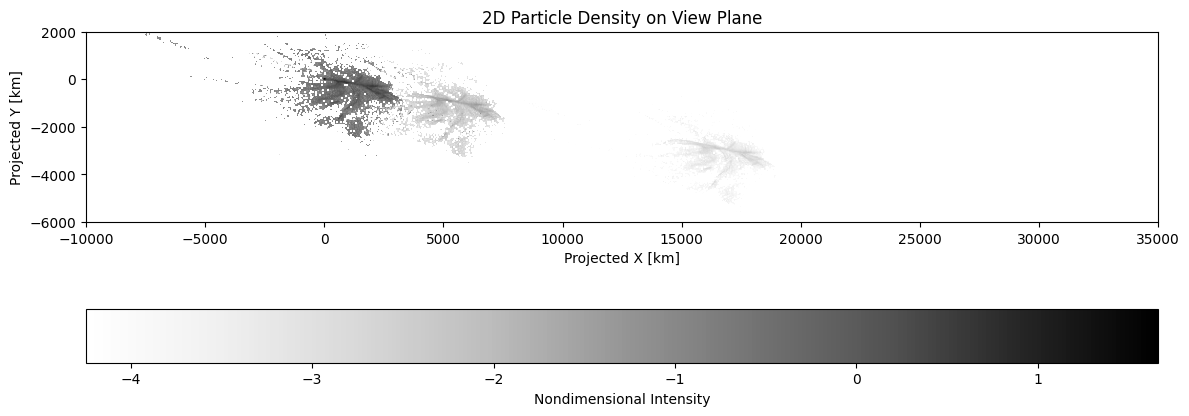

In [62]:
# Plot the 2D histogram
plt.figure(figsize=(12, 9))
im = plt.imshow(
    np.log(total_inten).T,
    #total_inten.T,
    origin='lower',
    extent=[val / 1e3 for val in axlims],
    aspect='equal',
    cmap='Greys'
)
plt.xlabel('Projected X [km]')
plt.ylabel('Projected Y [km]')
plt.title('2D Particle Density on View Plane')
plt.grid(False)

cbar = plt.colorbar(im, orientation='horizontal', pad=0.1)  # pad adjusts spacing
cbar.set_label('Nondimensional Intensity')

plt.tight_layout()

output_name = os.path.join(output_dir, f"tail_synt.png")
plt.savefig(output_name, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

In [54]:
# Extract data at a time slices and save data
import os
import pickle

# data path
data_rootdir = "/home/linfel/linfel_data/ejecta_size_exp"
filenames = [os.path.join(data_rootdir, f"run_{i:03d}", "particles.txt") for i in range(1, 3)]

# Ensure output directory exists for saving frames
output_dir = "/home/linfel/linfel_data/ejecta_size_exp/day131.29"
os.makedirs(output_dir, exist_ok=True)

# specify time
target_day = 131.29
target_seconds = target_day * 86400.

i = 1
for file in filenames:
    # Read particle data
    Np_seq, time, radii_dust, data_p = read_particle_frames(file)

    t_idx = np.searchsorted(time, target_seconds, side="left")
    p_t = data_p[t_idx]
    day = time[t_idx] / 86400.

    # Create a dictionary with the data
    save_data = {
        "radii_dust": radii_dust,
        "p_t": p_t,
        "day":day
    }

    # Create output filename based on dust radius or file index
    output_name = os.path.join(output_dir, f"particle_{i:03d}_day{target_day:.2f}.pkl")

    # Save using pickle
    with open(output_name, 'wb') as f:
        pickle.dump(save_data, f)

    # Optional: clean up memory
    del data_p

    i = i + 1

processing completed!
processing completed!


In [ ]:
load

In [20]:
# Calculate phase angle of dust particles

# Compute vectors
vec_sun = r_sun - r_dust      # Vectors from dust particles to Sun 
vec_earth = r_earth - r_dust  # Vectors from dust particles to Earth

# Compute norms
norm_sun = np.linalg.norm(vec_sun, axis=1)  # Magnitudes of Sun vectors
norm_earth = np.linalg.norm(vec_earth, axis=1)  # Magnitudes of Earth vectors

# Compute dot products
dot_product = np.einsum('ij,ij->i', vec_sun, vec_earth)  # Dot product of Sun and Earth vectors

# Compute phase angles
cos_theta = dot_product / (norm_sun * norm_earth)      # cosine of angle between two vectors
mu = - np.clip(cos_theta, -1.0, 1.0)             # cosine of scattering phase angle

In [2]:
Np_seq, time, r_dust, data_p = read_particle_frames('particles_4mm.txt')

processing completed!


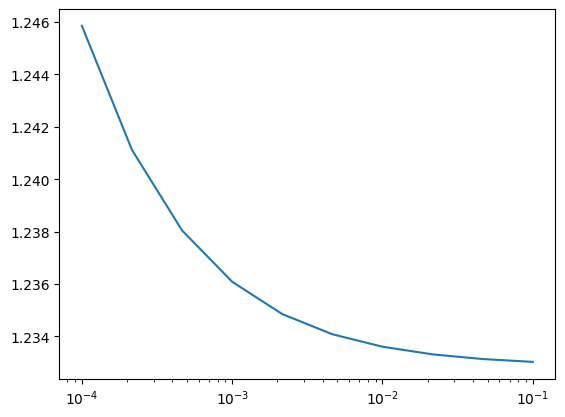

In [4]:
import miepython as mie

I0 = 1            # incident solar flux at the particle location
m = 1.5 - 1j      # refractive index of sphere
r = 10**np.linspace(-4,-1,10)          # m radius of sphere
lambda0 = 500e-9  # m wavelength in vacuum
x = 2*np.pi*r/lambda0

qext, qsca, qback, g = mie.efficiencies(m, 2*r, lambda0)

plt.plot(r, qsca)
plt.xscale('log')

In [21]:
import miepython as mie

I0 = 1            # incident solar flux at the particle location
m = 1.5 - 1j      # refractive index of sphere
r = 1e-3          # m radius of sphere
lambda0 = 500e-9  # m wavelength in vacuum
x = 2*np.pi*r/lambda0

qext, qsca, qback, g = mie.efficiencies(m, 2*r, lambda0)

# print("The extinction efficiency  is %.3f" % qext)
# print("The scattering efficiency  is %.3f" % qsca)
# print("The backscatter efficiency is %.3f" % qback)
# print("The scattering anisotropy  is %.3f" % g)

P_func = mie.i_unpolarized(m, x, mu)        # check how phase function is normalized.

I_sc = I0 * qsca * P_func

# --- Normalize intensity to 0–1 for alpha ---
alpha_vals = I_sc / np.max(I_sc)
#alpha_vals = np.clip(alpha_vals, 0.05, 1.0)

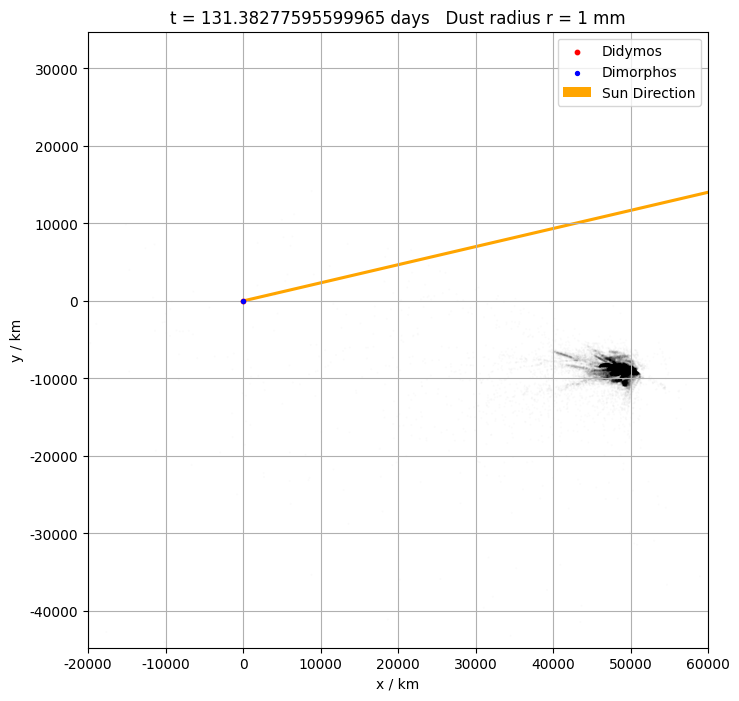

In [23]:
from matplotlib.ticker import FuncFormatter

axis_lims = [-20000e3, 60000e3, -20000e3, 10000e3]    # m

# Convert length unit for axis labels
def m_to_km(x, _):
    return f'{x / 1e3:.0f}'

# Create a new figure for this frame
fig, ax = plt.subplots(figsize=(8, 8))

# plot Didymos and Dimorphos
ax.scatter(p_projected[0, 1], p_projected[0, 2], c='red', s=10, zorder=3, label='Didymos')
ax.scatter(p_projected[1, 1], p_projected[1, 2], c='blue', s=8, zorder=3, label='Dimorphos')

# plot dust particles
dust_sca = ax.scatter(p_projected[4:, 1], p_projected[4:, 2], c='k', s=0.5, alpha=)

# To set individual alphas, you need to use RGBA colors
colors = np.zeros((len(I_sc), 4))  # RGBA
colors[:, 3] = alpha_vals  # only alpha, rest stays black

dust_sca.set_facecolors(colors)

# Plot Sun direction relative to Didymos System Barycenter
sun_x, sun_y = p_projected[2, 1], p_projected[2, 2]
sun_distance = (sun_x**2 + sun_y**2) ** 0.5
arrow_x = sun_x / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
arrow_y = sun_y / sun_distance * (ax.get_xlim()[1] - ax.get_xlim()[0]) * 0.1
ax.quiver(0, 0, arrow_x, arrow_y, angles='xy', scale_units='xy', scale=1, width=0.005, color='orange', label='Sun Direction')

# Customize axis
ax.xaxis.set_major_formatter(FuncFormatter(m_to_km))
ax.yaxis.set_major_formatter(FuncFormatter(m_to_km))

# Determine axis limit
ax.axis('equal')
ax.set_xlim(axis_lims[0], axis_lims[1])
ax.set_ylim(axis_lims[2], axis_lims[3])
ax.set_xlabel('x / km')
ax.set_ylabel('y / km')
ax.grid()
ax.legend(loc='upper right')

# Set title
ax.set_title(f't = {day} days   Dust radius r = 1 mm')

# Save the frame as a PNG image
#frame_filename = os.path.join(output_dir, f"frame_{frame:04d}.png")
#plt.savefig(frame_filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)